In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('data.csv')

data.head()

y = data.iloc[:, 0]  # Bankrupt
X = data.iloc[:, 1:]  # All 95 features

print(f"Total companies: {len(data)}")
print(f"Bankruptcies: {y.sum()}")
print(f"Bankruptcy rate: {y.mean():.2%}")

Total companies: 6819
Bankruptcies: 220
Bankruptcy rate: 3.23%


Features shape: (6819, 95)
Top correlations with target:
Bankrupt?                               1.000000
 Debt ratio %                           0.250161
 Current Liability to Assets            0.194494
 Borrowing dependency                   0.176543
 Current Liability to Current Assets    0.171306
 Liability to Equity                    0.166812
 Current Liabilities/Equity             0.153828
 Current Liability to Equity            0.153828
 Liability-Assets Flag                  0.139212
 Total expense/Assets                   0.139049
Name: Bankrupt?, dtype: float64
Strongest negative correlations with target:
Per Share Net profit before tax (Yuan ¥)                  -0.201395
Net profit before tax/Paid-in capital                     -0.207857
Retained Earnings to Total Assets                         -0.217779
Persistent EPS in the Last Four Seasons                   -0.219560
Net worth/Assets                                          -0.250161
ROA(C) before interest and depreciat

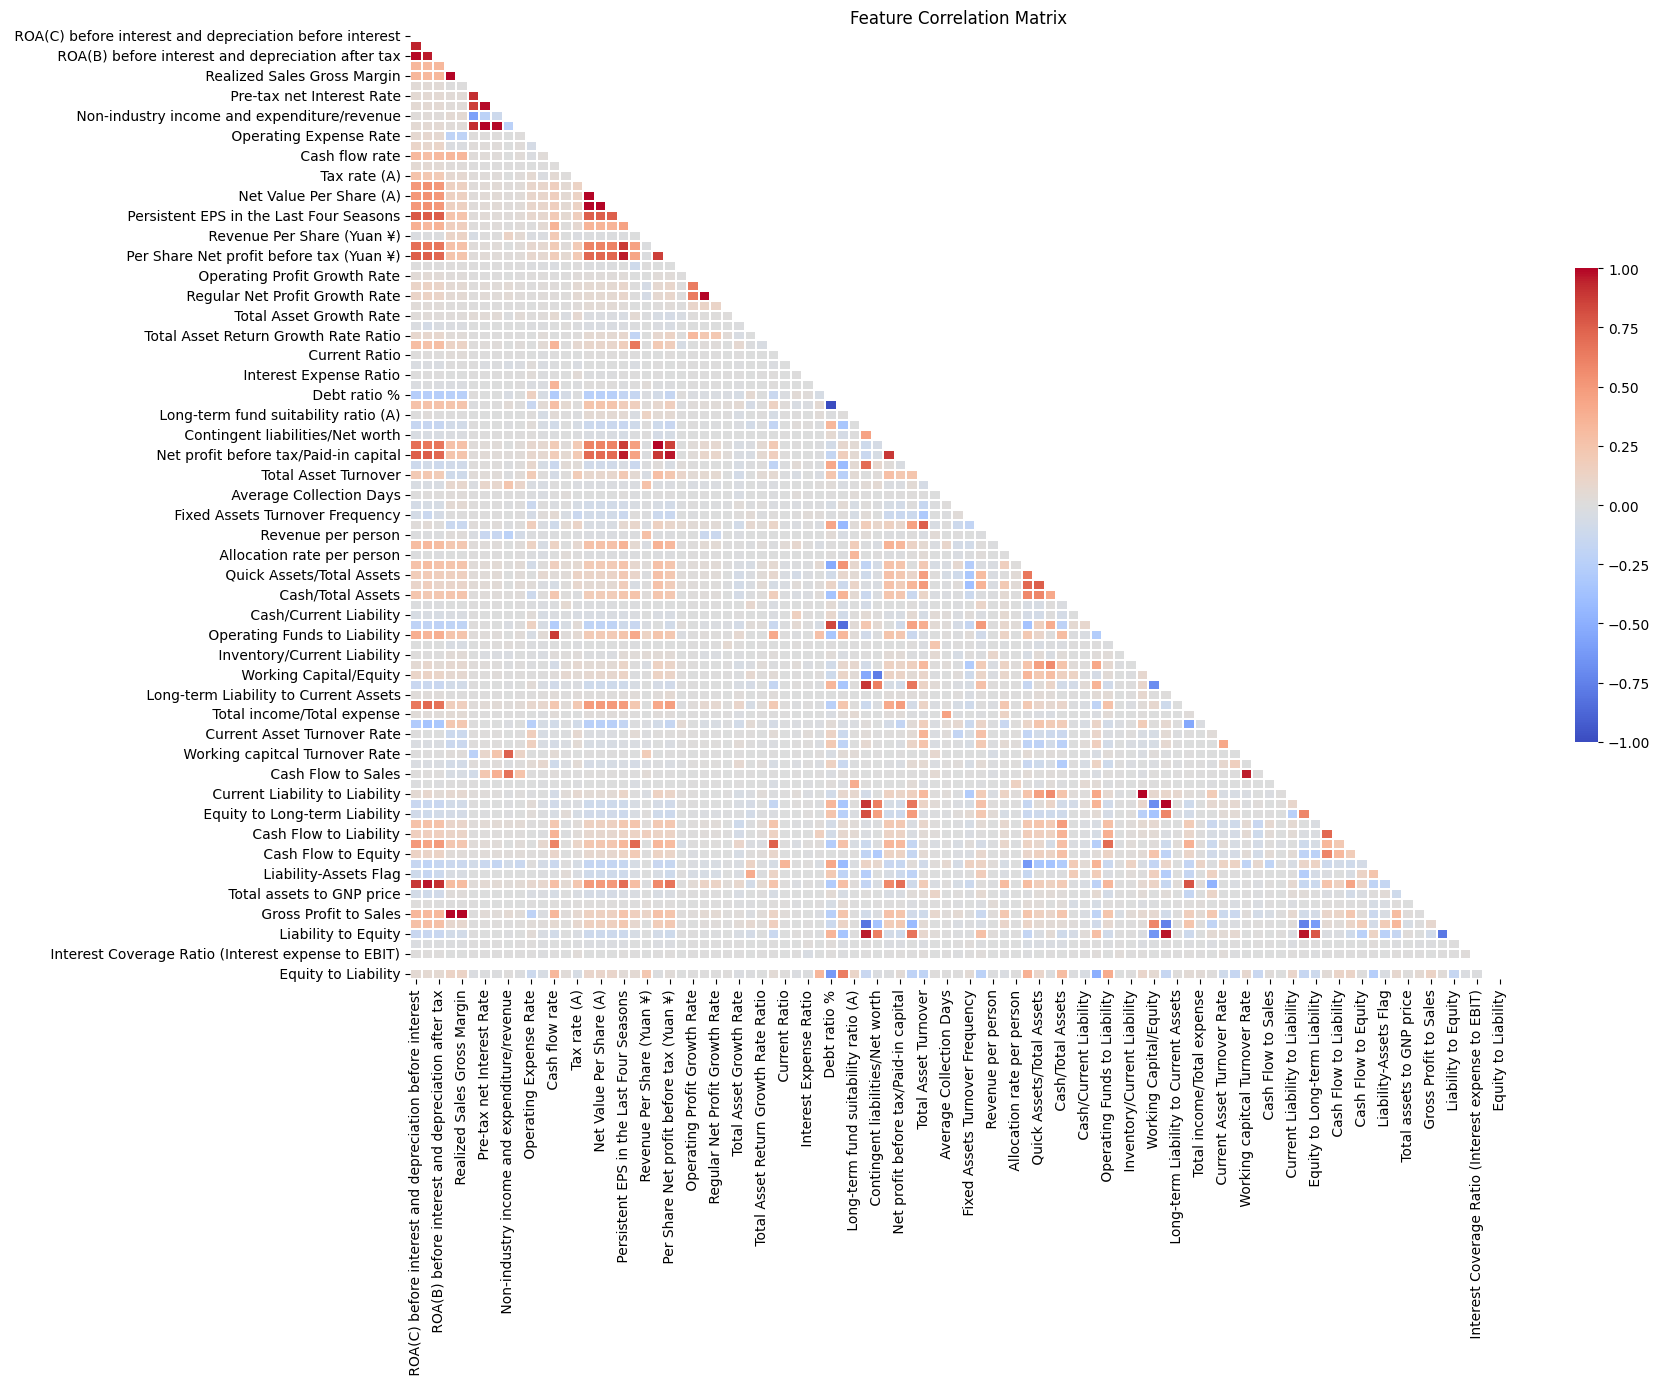

In [7]:
# compute correlations only between features (exclude target column)
target_col = data.columns[0]  # "Bankrupt?"
X = data.drop(columns=[target_col])

# feature correlation matrix
corr = X.corr()
print(f"Features shape: {X.shape}")

# correlations with the target (for reference)
corr_with_target = data.corr()[target_col].sort_values(ascending=False)
print("Top correlations with target:")
print(corr_with_target.head(10))
print("Strongest negative correlations with target:")
print(corr_with_target.tail(10))

# function returning strongly correlated pairs
def high_corr_pairs(corr_df, thresh=0.8):
    pairs = corr_df.where(np.triu(np.ones(corr_df.shape), k=1).astype(bool)).stack()
    return pairs[abs(pairs) > thresh].sort_values(ascending=False)

thresh = 0.9
strong_pairs = high_corr_pairs(corr, thresh)
print(f"\nFeature pairs with |corr| > {thresh} (count: {len(strong_pairs)}):")
print(strong_pairs)

# function proposing redundant features to drop (deterministic: drop the second feature in each pair)
def get_redundant_features(corr_df, thresh=0.9):
    to_drop = set()
    cols = corr_df.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            if abs(corr_df.iloc[i, j]) > thresh:
                to_drop.add(cols[j])
    return sorted(to_drop)

to_drop = get_redundant_features(corr, thresh)
print(f"\nProposed features to drop (|corr|>{thresh}): {len(to_drop)}")
print(to_drop)


# draw heatmap (mask upper triangle for readability)
plt.figure(figsize=(18,14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, vmin=-1, vmax=1, linewidths=0.01, cbar_kws={"shrink": .5})
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("feature_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
#We want to remove features that are highly correlated to make our model faster i guess